# Spring-Mass-Damper System 

Date: 13th Feb 2023

In this notebook, we illustrate the input-output characterization of a spring mass damper system using the following three methods 

1. Numerical Integration of the ODE 
2. Frequency Response 
3. Convolution of the Impulse Response

The governing equations of motion for the system are 

$m \ddot{x} + c \dot{x} + k x = F $

The FRF of the system is given by 

$ H(\omega) = \frac{1}{-m \omega^2 + k + i c \omega}$

The input for the system is the force $F(t)$

The output for the system is the displacement $x(t)$

For the purpose of the present demonstration $F(t) = F cos (\omega t) $

Impulse response for the system is given by 

$h(t) = \frac{e^{-\zeta \omega_n t}sin (\omega_d t)}{m \omega_d}$ where 

$\zeta = \frac{c}{2 \sqrt{km}}$
$\omega_d = \sqrt{1-\zeta^2} \omega_n$
$\omega_n = \sqrt{k/m}$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy import integrate

In [2]:
m = 1
c = 0.2
k = 1

def force(t):
    return np.cos(t)

def sdof_fun(y, t):
    '''Returns the derivative of the state vector y at a time t'''
    y0dot = y[1]
    y1dot = (force(t)-c*y[1]-k*y[0])/m 
    return np.array([y0dot, y1dot])

tvec = np.linspace(0, 100, 500)

sol = integrate.odeint(sdof_fun, np.array([0, 0]), tvec)

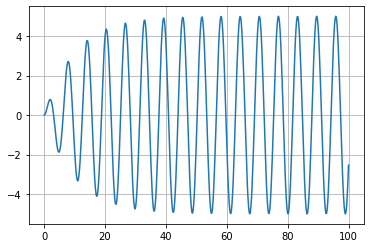

In [3]:
disp = sol[:, 0]
vel = sol[:, 1]
plt.plot(tvec, disp)
plt.grid()

## Frequency Response Function 

In [5]:
def sdof_frf(w):
    '''Given w the FRF has to be returned'''
    return 1/(-m*w*w+k+1.0j*w*c)

forcing_w = np.array([-1.0, 1.0])
forcing_amp = np.array([1/2, 1/2])
resp_frf = np.zeros_like(tvec, dtype=complex)

for count in range(len(forcing_w)):
    resp_frf = resp_frf+sdof_frf(forcing_w[count])*forcing_amp[count]*np.exp(1.0j*forcing_w[count]*tvec)

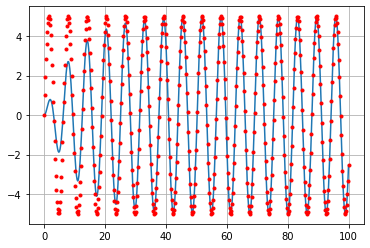

In [7]:
plt.plot(tvec, disp)
plt.plot(tvec, np.real(resp_frf), 'r.')
plt.grid()

The FRF is able to capture the steady state behaviour accurately. 

The transient response cannot be captured through FRF since the complex exponentials are non-zero for t<0

## Convolution

Define the impulse response of the system

In [8]:
def impulse_response(t):
    '''Returns the impulse response at a time t'''
    wn = np.sqrt(k/m)
    zeta = c/(2*np.sqrt(k*m))
    wd = wn*np.sqrt(1-zeta**2)
    ansr = np.exp(-zeta*wn*t)*np.sin(wd*t)
    ansr1 = ansr/(m*wn*np.sqrt(1-zeta**2))
    
    if t>=0:
        final_ansr = ansr1 
    else:
        final_ansr = 0 
        
    return final_ansr 

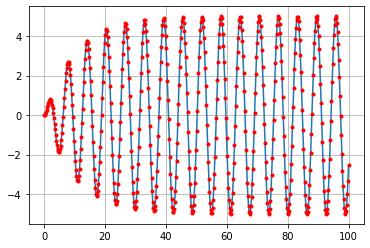

In [9]:
def intgrnd(tau, somet):
    return force(tau)*impulse_response(somet-tau)

resp_conv = np.zeros_like(tvec)

for count in range(len(tvec)):
    time = tvec[count]
    ansr, err = integrate.quad(intgrnd, 0, time, args = (time,))
    resp_conv[count] = ansr 
    
plt.plot(tvec, resp_conv)
plt.plot(tvec, disp, 'r.')
plt.grid()